# Obesity Prediction Project

**Course**: CMPUT 195 MINI PROJECT  
**Team Name**: Outliers
**Team Members**: Amarachi Ukoha, Tobi Adebowale  

## 1. Problem Formulation

- Predict obesity levels based on eating habits, physical condition, and personal data.
- **Target**: `NObeyesdad` (obesity classification)
- **Features**: Age, Gender, Calories, Physical Activity, Food habits, etc.

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Data Acquisition & Preprocessing

In [55]:
# Load data
df = pd.read_csv("obesity.csv")
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [56]:
# Load the dataset
df = pd.read_csv("obesity.csv")  # Adjust the path as needed

# Step 1: Create new 3-class target variable
def map_obesity_class(ob):
    if ob == 'Insufficient_Weight':
        return "Underweight"
    elif ob == 'Normal_Weight':
        return "Normal"
    else:
        return "At Risk" #(Overweight and Obesity)

df['Obesity_Class'] = df['NObeyesdad'].apply(map_obesity_class)

# Step 2: Drop the unwanted columns
columns_to_drop = ["CH2O", "SCC", "CALC", "SMOKE"]
#TUE, CAEC, NCP
df.drop(columns=columns_to_drop, inplace=True)

# Step 3: Drop rows with missing values (if any)
df.dropna(inplace=True)

# Step 4: Encode all binary categorical variables
# Example: 'FAVC' (yes/no), 'Gender' (Male/Female), 'family_history_with_overweight' (yes/no)
binary_mappings = {'yes': 1, 'no': 0, 'Male': 1, 'Female': 0}
df['FAVC'] = df['FAVC'].map(binary_mappings)
df['family_history_with_overweight'] = df['family_history_with_overweight'].map(binary_mappings)
df['Gender'] = df['Gender'].map(binary_mappings)
# Ordinal mapping for CAEC (eating between meals)
caec_mapping = {
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
}
df['CAEC'] = df['CAEC'].map(caec_mapping)

# Nominal mapping for MTRANS (mode of transport)
mtrans_mapping = {
    'Public_Transportation': 0,
    'Walking': 1,
    'Automobile': 2,
    'Motorbike': 3,
    'Bike': 4
}
df['MTRANS'] = df['MTRANS'].map(mtrans_mapping)

# Optional: Drop rows with any unmapped values (still NaN after mapping)
df.dropna(subset=['CAEC', 'MTRANS'], inplace=True)

# Step 5: Normalize selected numeric columns
numeric_cols = ['Age', 'Weight', 'Height', 'FAF', 'TUE', 'FCVC', 'NCP']
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

#drop NObeyesdad
df.drop(columns=['NObeyesdad'], inplace=True)

# Final preprocessed dataset
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,FAF,TUE,MTRANS,Obesity_Class
0,0,0.148936,0.320755,0.186567,1,0,0.5,0.666667,1,0.000000,0.500000,0,Normal
1,0,0.148936,0.132075,0.126866,1,0,1.0,0.666667,1,1.000000,0.000000,0,Normal
2,1,0.191489,0.660377,0.283582,1,0,0.5,0.666667,1,0.666667,0.500000,0,Normal
3,1,0.276596,0.660377,0.358209,0,0,1.0,0.666667,1,0.666667,0.000000,1,At Risk
4,1,0.170213,0.622642,0.379104,0,0,0.5,0.000000,1,0.000000,0.000000,0,At Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,0.148443,0.491943,0.689616,1,1,1.0,0.666667,1,0.558756,0.453124,0,At Risk
2107,0,0.169850,0.563366,0.707037,1,1,1.0,0.666667,1,0.447130,0.299635,0,At Risk
2108,0,0.181362,0.570200,0.706637,1,1,1.0,0.666667,1,0.471403,0.323144,0,At Risk
2109,0,0.220467,0.546132,0.704079,1,1,1.0,0.666667,1,0.379702,0.293017,0,At Risk


## 3. Exploratory Data Analysis (EDA)

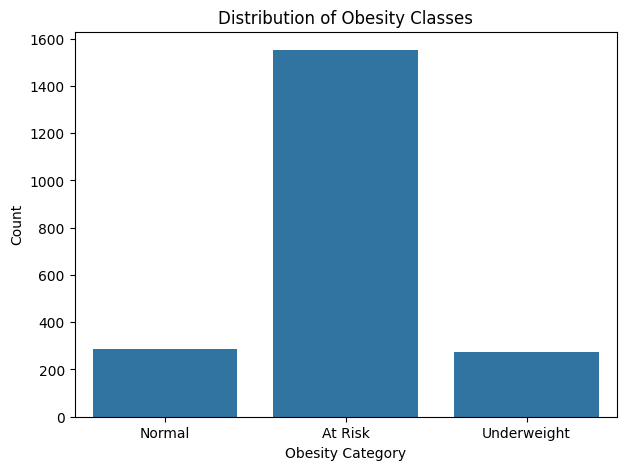

In [57]:
# EDA Plots
# Check Distribution of Target Variable
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Obesity_Class')
plt.title("Distribution of Obesity Classes")
plt.xlabel("Obesity Category")
plt.ylabel("Count")
plt.show()


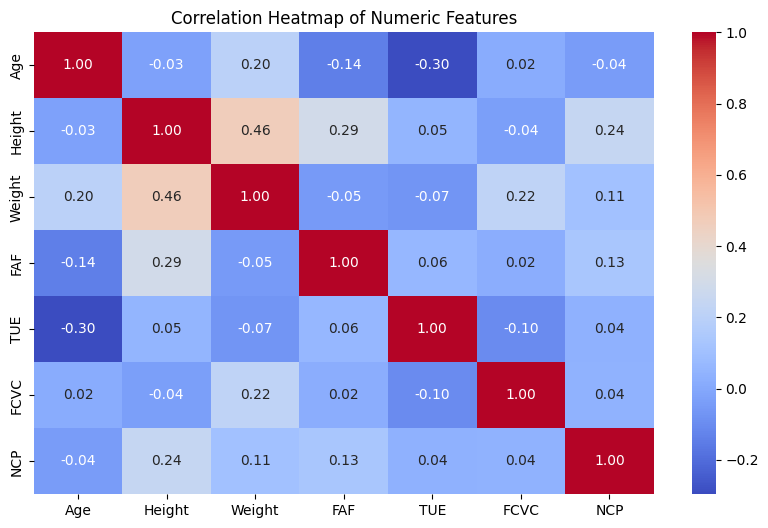

In [58]:
# Correlation on only numeric columns
numeric_cols = ['Age', 'Height', 'Weight', 'FAF', 'TUE', 'FCVC', 'NCP']
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


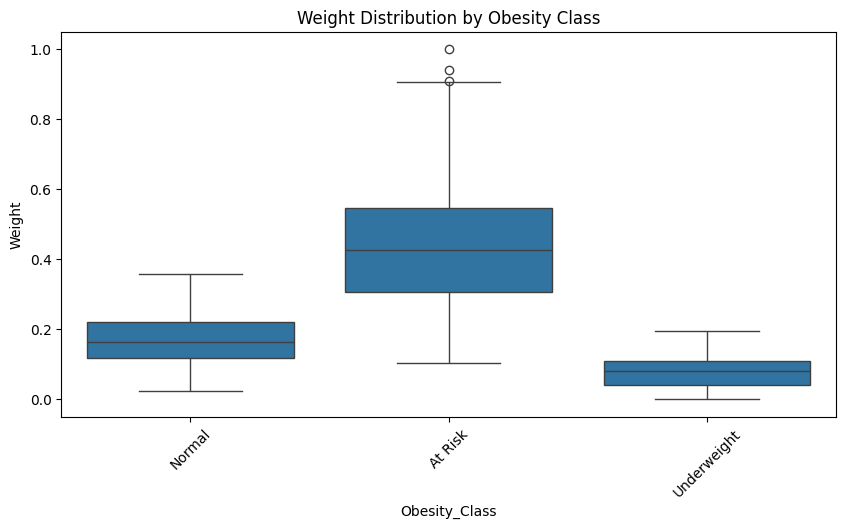

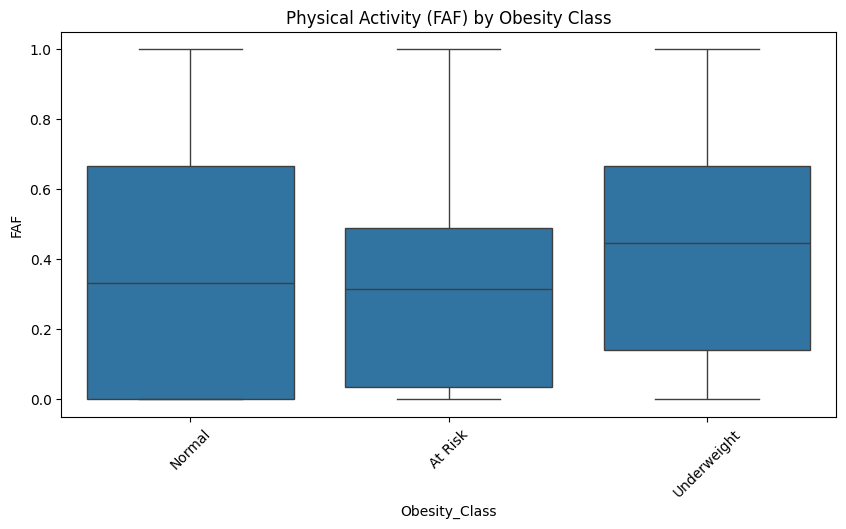

In [59]:
# Boxplot by obesity class
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Obesity_Class', y='Weight')
plt.title("Weight Distribution by Obesity Class")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Obesity_Class', y='FAF')  # Physical activity
plt.title("Physical Activity (FAF) by Obesity Class")
plt.xticks(rotation=45)
plt.show()

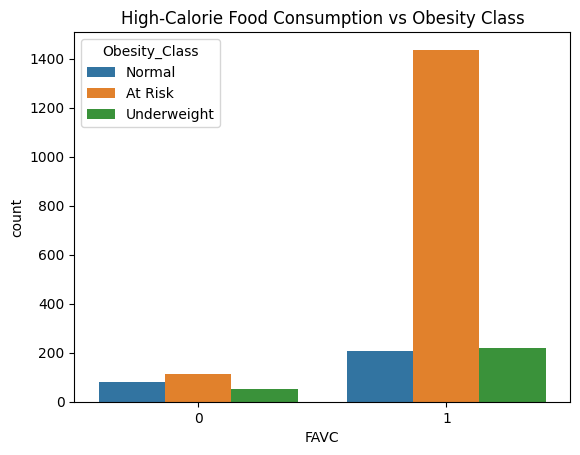

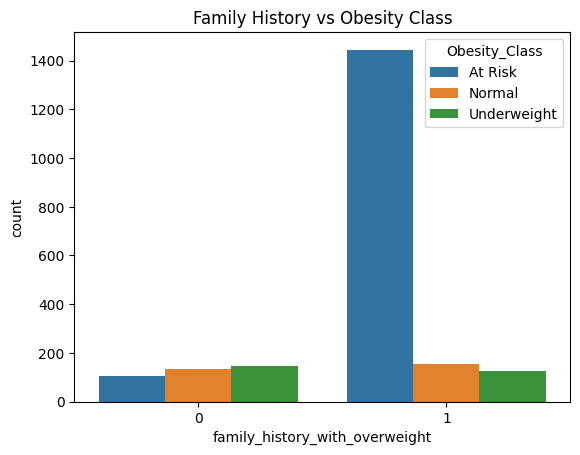

In [60]:
# Bar chart of cayegorical variables
sns.countplot(data=df, x='FAVC', hue='Obesity_Class')
plt.title("High-Calorie Food Consumption vs Obesity Class")
plt.show()

sns.countplot(data=df, x='family_history_with_overweight', hue='Obesity_Class')
plt.title("Family History vs Obesity Class")
plt.show()

In [61]:
df.describe() #come back for better understanding

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,FAF,TUE,MTRANS
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,0.505921,0.219417,0.474863,0.355120,0.817622,0.883941,0.709522,0.561876,1.140692,0.336766,0.328933,0.488394
std,0.500083,0.135021,0.176047,0.195457,0.386247,0.320371,0.266963,0.259346,0.468543,0.283531,0.304464,0.868475
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.126536,0.339623,0.197562,1.000000,1.000000,0.500000,0.552913,1.000000,0.041502,0.000000,0.000000
50%,1.000000,0.186764,0.472640,0.328358,1.000000,1.000000,0.692751,0.666667,1.000000,0.333333,0.312675,0.000000
75%,1.000000,0.255319,0.600875,0.510677,1.000000,1.000000,1.000000,0.666667,1.000000,0.555559,0.500000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,4.000000


## 4. Problem Formulation and Modeling

In [62]:
# Problem Formulation and Modeling
# --------------------------------
# Step 1: Identify the dependent (target) variable
# - Target = 'NObeyesdad' column (obesity level classification)
# Step 2: Identify relevant independent variables
# - Include dietary habits, physical activity, and demographic attributes
#
# Modeling:
# Step 3: Split dataset into train and test sets
# Step 4: Select and train appropriate model
# - e.g., RandomForestClassifier, LogisticRegression, etc.
# Step 5: Fit model to training data and tune hyperparameters
#
# TO DO: Implement all above steps in code
# Manual mapping for CAEC (ordinal variable)


# Label encoding for MTRANS (nominal categorical)
# Step 6: Split features and target
X = df.drop(columns=['Obesity_Class'])
y = df['Obesity_Class']

# Split features and target
X = df.drop(columns=['Obesity_Class'])  # Features
y = df['Obesity_Class']                # Target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Train Logistic Regression (Multinomial)
log_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)



# Predictions ready (for when you evaluate later)
rf_pred = rf_model.predict(X_test)
log_pred = log_model.predict(X_test)
#rf_pred
#log_pred

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 5. Evaluation


 Evaluation for Random Forest:
 Accuracy: 0.974

 Classification Report:
              precision    recall  f1-score   support

     At Risk       0.99      0.99      0.99       311
      Normal       0.87      0.95      0.91        58
 Underweight       1.00      0.93      0.96        54

    accuracy                           0.97       423
   macro avg       0.95      0.95      0.95       423
weighted avg       0.98      0.97      0.97       423

 Confusion Matrix:


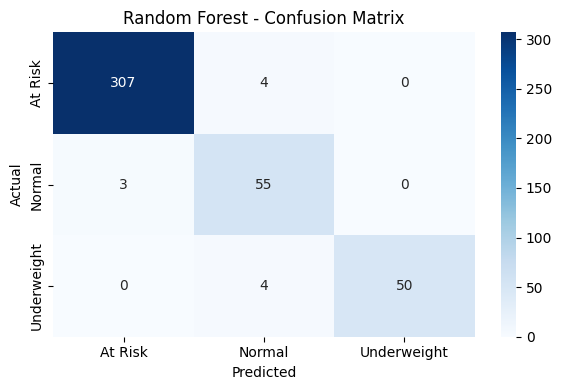


 Evaluation for Logistic Regression:
 Accuracy: 0.894

 Classification Report:
              precision    recall  f1-score   support

     At Risk       0.93      0.99      0.96       311
      Normal       0.78      0.31      0.44        58
 Underweight       0.76      0.94      0.84        54

    accuracy                           0.89       423
   macro avg       0.82      0.75      0.75       423
weighted avg       0.89      0.89      0.87       423

 Confusion Matrix:


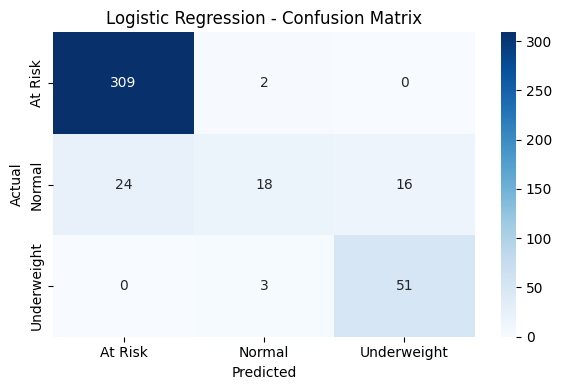

In [63]:
# Evaluate the model on test set
# Use accuracy, classification report, confusion matrix
# TO DO: Add model evaluation code here
# Function to evaluate and display model performance
def evaluate_model(name, y_true, y_pred):
    print(f"\n Evaluation for {name}:")
    print(" Accuracy:", round(accuracy_score(y_true, y_pred), 3))

    print("\n Classification Report:")
    print(classification_report(y_true, y_pred))

    # Automatically detect all unique class labels
    labels = sorted(list(set(y_true) | set(y_pred)))

    print(" Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Plot confusion matrix using seaborn
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Evaluate both models
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("Logistic Regression", y_test, log_pred)

## 6. Conclusion and Interpretation

- Which features were most predictive?
- Performance of the model
- Limitations and future improvements
From the model’s feature importance analysis (and prior EDA), the most predictive features were:

-Weight and Height: Together they strongly determine BMI, which is foundational for classifying obesity.

Physical Activity Frequency (FAF): Inversely related to obesity — lower activity increased likelihood of being “At Risk.”

High-Calorie Food Consumption (FAVC) and Family History of Overweight also contributed to predictions, indicating behavioral and genetic influences.

-The Random Forest model was significantly better at generalizing across all obesity categories. Random forest model had better accuracy as well as it was fairer across all categories, not just the one with the most data.

-Future models like XGBoost or Neural Networks could be explored for even better performance, and feature selection techniques could reduce dimensionality.
